**Loan Default Prediction System**

In [ ]:
#Import necesassry libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score
sns.set_style('whitegrid')

In [ ]:
# Load the data
df = pd.read_csv('/content/Loan_default.csv')

In [ ]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0.0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0.0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1.0
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0.0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0.0


In [ ]:
df.shape

(204844, 18)

In [ ]:
df.isnull().sum().sum()

np.int64(6)

In [ ]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,204844.000000,204844.000000,204844.000000,204844.000000,204844.000000,204844.000000,204844.000000,204844.000000,204844.000000,204843.000000
mean,43.465969,82492.914808,127430.754613,574.451475,59.561237,2.500605,13.491592,36.049853,0.500040,0.116226
std,14.984015,38978.282729,70828.623080,158.880039,34.623470,1.116944,6.632018,16.967362,0.230782,0.320496
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48772.000000,66016.500000,437.000000,30.000000,2.000000,7.780000,24.000000,0.300000,0.000000
50%,43.000000,82536.500000,127303.500000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116184.500000,188742.500000,712.000000,90.000000,3.000000,19.240000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


Object `default` not found.
Default rate: 11.6%


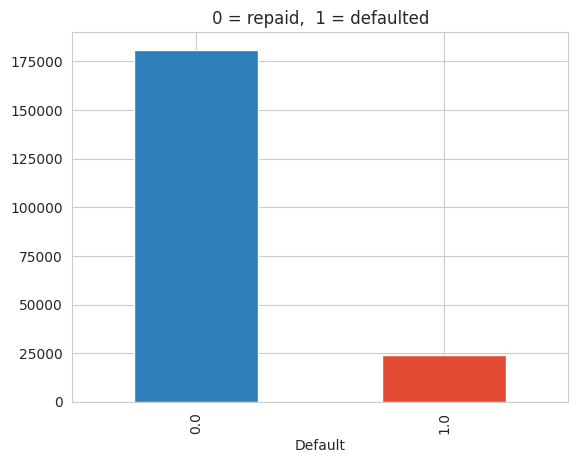

In [ ]:
Target balance — what % actually default?
rate = df['Default'].mean()
print(f'Default rate: {rate:.1%}')
df['Default'].value_counts().plot(kind='bar', color=['#2c7fb8','#e34a33'])
plt.title('0 = repaid,  1 = defaulted'); plt.show()
# NOTE: only ~12% default. The data is imbalanced — keep an eye on F1, not just accuracy.

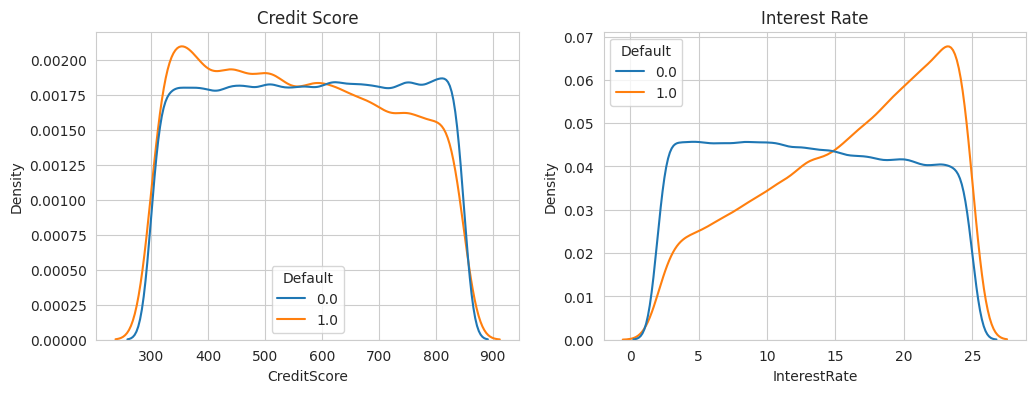

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.kdeplot(data=df, x='CreditScore', hue='Default', common_norm=False, ax=ax[0])
ax[0].set_title('Credit Score')
sns.kdeplot(data=df, x='InterestRate', hue='Default', common_norm=False, ax=ax[1])
ax[1].set_title('Interest Rate')
plt.show()

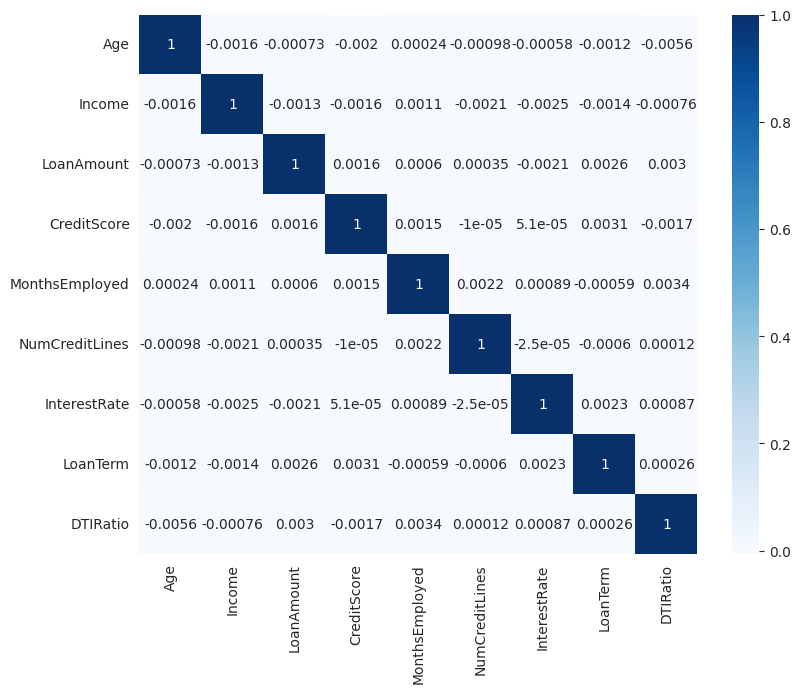

In [ ]:
# correction
num = ['Age','Income','LoanAmount','CreditScore','MonthsEmployed',
       'NumCreditLines','InterestRate','LoanTerm','DTIRatio']
plt.figure(figsize=(9,7))
sns.heatmap(df[num].corr(), annot=True, cmap='Blues')
plt.show()


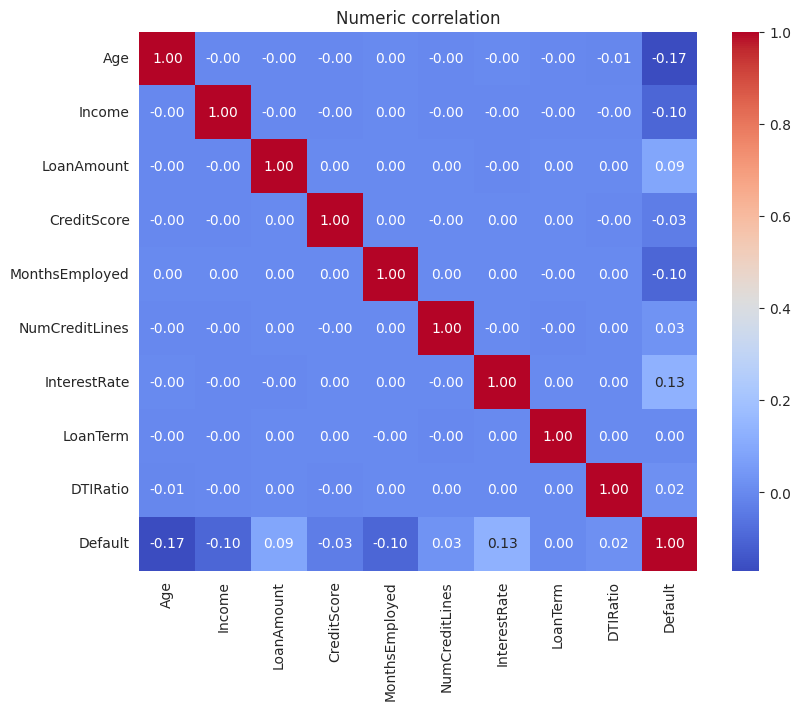

In [ ]:
# correction
num = ['Age','Income','LoanAmount','CreditScore','MonthsEmployed',
       'NumCreditLines','InterestRate','LoanTerm','DTIRatio']
plt.figure(figsize=(9,7))
sns.heatmap(df[num+['Default']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Numeric correlation'); plt.show()

In [ ]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0.0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0.0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1.0
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0.0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0.0


One-hot encoding

In [ ]:
df_enc = pd.get_dummies(df.drop(columns=['LoanID']), drop_first=True)
df_enc = df_enc.dropna(subset=['Default']) # Drop rows where 'Default' is NaN
X = df_enc.drop(columns=['Default'])
y = df_enc['Default']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (163874, 25)  Test: (40969, 25)


MODEL BUILDING

**Logistic Regression**

In [ ]:
# Train a Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets and binary classification
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)

print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")
print(f"Logistic Regression F1-Score: {f1_log_reg:.4f}")

Logistic Regression Accuracy: 0.8844
Logistic Regression F1-Score: 0.0154


Logistic Regression Feature Importance

In [ ]:
# Feature Importance for Logistic Regression

feature_importance_log = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg_model.coef_[0]
})

# Sort by absolute importance
feature_importance_log['Absolute_Coefficient'] = abs(
    feature_importance_log['Coefficient']
)

feature_importance_log = feature_importance_log.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

feature_importance_log

,Feature,Coefficient,Absolute_Coefficient
0,Age,-0.041000,0.041000
6,InterestRate,0.027404,0.027404
4,MonthsEmployed,-0.009679,0.009679
7,LoanTerm,0.003015,0.003015
5,NumCreditLines,0.000956,0.000956
24,HasCoSigner_Yes,-0.000738,0.000738
19,HasDependents_Yes,-0.000686,0.000686
15,EmploymentType_Unemployed,0.000574,0.000574
3,CreditScore,-0.000507,0.000507
16,MaritalStatus_Married,-0.000483,0.000483


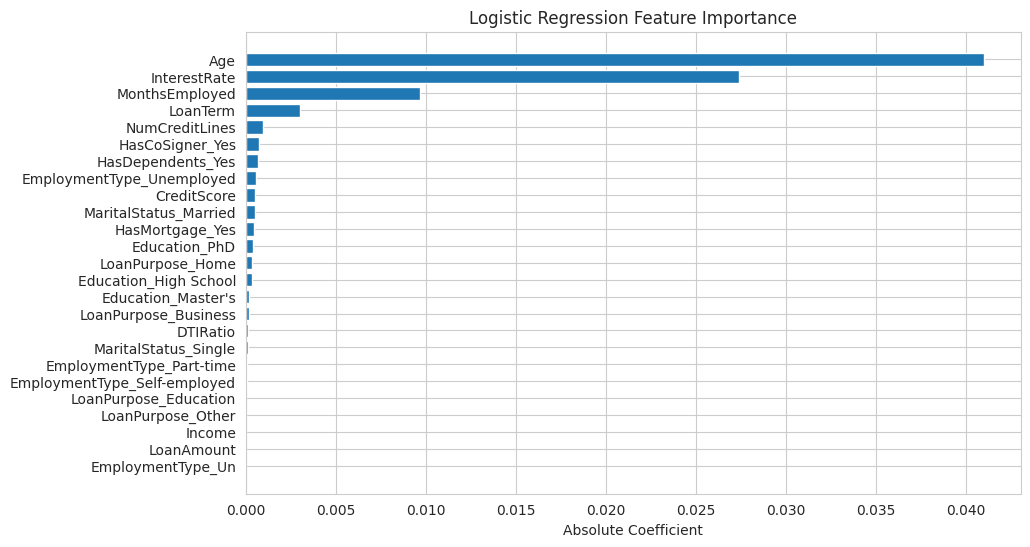

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_log['Feature'],
    feature_importance_log['Absolute_Coefficient']
)

plt.title("Logistic Regression Feature Importance")
plt.xlabel("Absolute Coefficient")
plt.gca().invert_yaxis()
plt.show()

**Random Forest**

In [ ]:
# Random Forest

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest F1-Score: {f1_rf:.4f}")

Random Forest Accuracy: 0.8852
Random Forest F1-Score: 0.0329


Random Forest Feature Importance

In [ ]:
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

feature_importance_rf

,Feature,Importance
0,Age,0.221289
1,Income,0.184745
6,InterestRate,0.165338
2,LoanAmount,0.121877
4,MonthsEmployed,0.101670
3,CreditScore,0.053406
8,DTIRatio,0.036768
5,NumCreditLines,0.013779
7,LoanTerm,0.013121
15,EmploymentType_Unemployed,0.010560


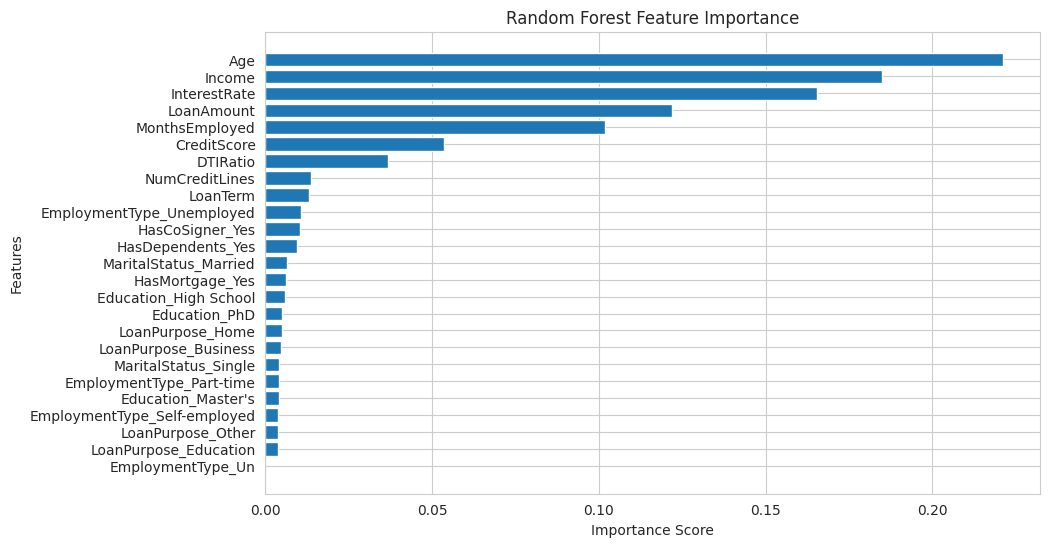

In [ ]:
# Random Forest Feature Importance

feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance_rf = feature_importance_rf.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_rf['Feature'],
    feature_importance_rf['Importance']
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.gca().invert_yaxis()
plt.show()

**XGBOOST**

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")
print(f"XGBoost F1-Score: {f1_xgb:.4f}")

XGBoost Accuracy: 0.8862
XGBoost F1-Score: 0.1244


XGBoost Feature Importance

In [ ]:
feature_importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

feature_importance_xgb

,Feature,Importance
0,Age,0.154959
6,InterestRate,0.079608
1,Income,0.070817
4,MonthsEmployed,0.056307
2,LoanAmount,0.055218
19,HasDependents_Yes,0.052357
15,EmploymentType_Unemployed,0.050894
24,HasCoSigner_Yes,0.050053
13,EmploymentType_Self-employed,0.046932
16,MaritalStatus_Married,0.044259


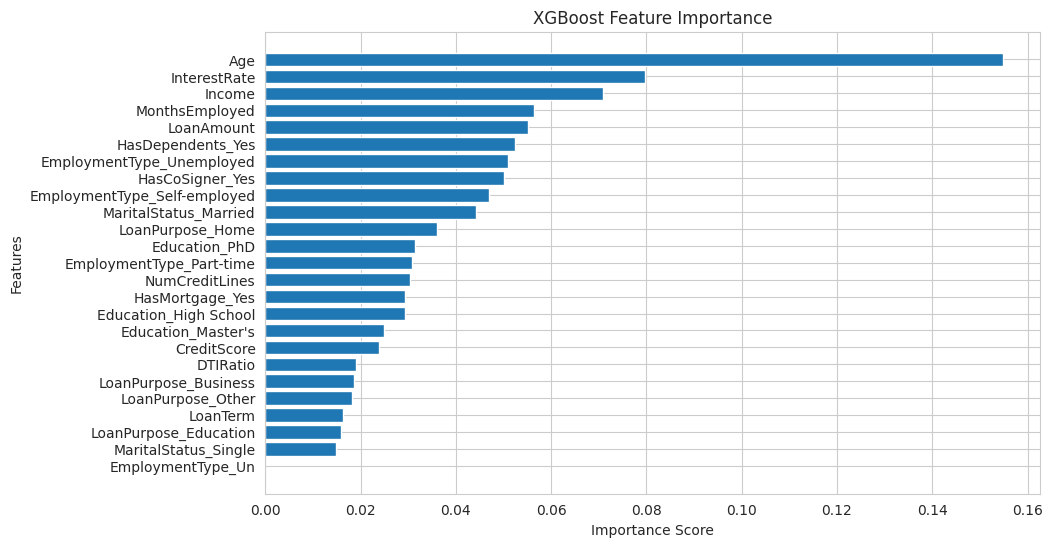

In [ ]:
# XGBoost Feature Importance

feature_importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_xgb['Feature'],
    feature_importance_xgb['Importance']
)

plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.gca().invert_yaxis()
plt.show()

**Compare All Three Models**

In [ ]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_log_reg,
        accuracy_rf,
        accuracy_xgb
    ],
    'F1 Score': [
        f1_log_reg,
        f1_rf,
        f1_xgb
    ]
})

comparison.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,F1 Score
2,XGBoost,0.886231,0.124366
1,Random Forest,0.885206,0.032902
0,Logistic Regression,0.884352,0.015378


**Visualize the Comparison**

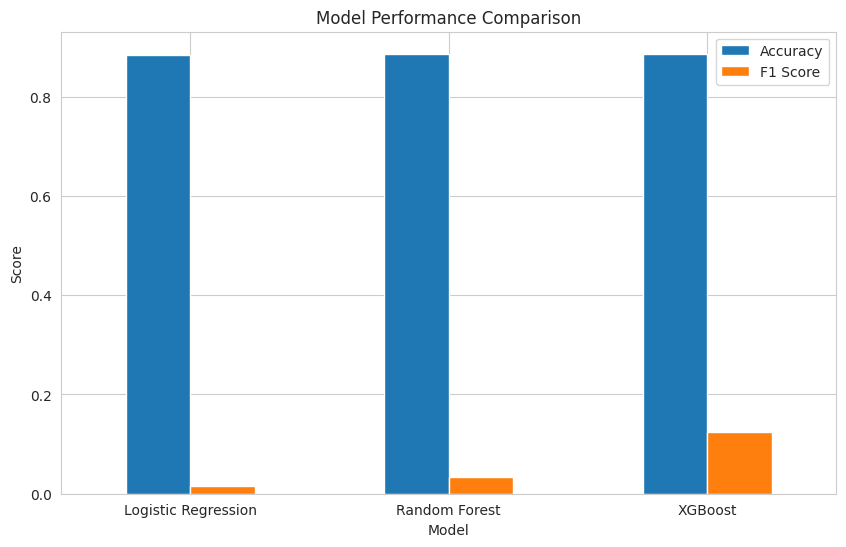

In [ ]:
comparison.set_index('Model')[['Accuracy','F1 Score']].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

**Select the Best Model Automatically**

In [ ]:
best_model_name = comparison.sort_values(
    by='F1 Score',
    ascending=False
).iloc[0]['Model']

print("Best Model:", best_model_name)

Best Model: XGBoost


**Save the Best Model**

In [ ]:
import joblib

if best_model_name == "Logistic Regression":
    best_model = log_reg_model

elif best_model_name == "Random Forest":
    best_model = rf_model

else:
    best_model = xgb_model

joblib.dump(best_model, "loan_default_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


**Streamlit Application**

**app.py**

In [55]:
app_py_content = """
import streamlit as st
import joblib
import pandas as pd

# PAGE CONFIGURATION

st.set_page_config(
    page_title="Loan Default Prediction",
    page_icon="💳",
    layout="wide"
)

# LOAD MODEL

model = joblib.load("loan_default_model.pkl")

# CUSTOM CSS

st.markdown('''
<style>

.main {
    background-color: #F8FAFC;
}

.title {
    text-align:center;
    color:#1E3A8A;
    font-size:45px;
    font-weight:700;
}

.subtitle {
    text-align:center;
    color:#64748B;
    font-size:18px;
}

.metric-card {
    background-color:white;
    padding:15px;
    border-radius:12px;
    box-shadow:0px 2px 10px rgba(0,0,0,0.08);
}

.stButton > button {
    width:100%;
    height:55px;
    border-radius:12px;
    font-size:18px;
    font-weight:bold;
}

</style>
''', unsafe_allow_html=True)

# SIDEBAR

with st.sidebar:

    st.image(
        "https://cdn-icons-png.flaticon.com/512/3135/3135715.png",
        width=150
    )

    st.title("📊 Project Overview")

    st.markdown('''
    ### Models Used

    - Logistic Regression
    - Random Forest
    - XGBoost

    ### Objective

    Predict whether a borrower is likely to default on a loan.

    ### Features

    - Real-time prediction
    - Risk probability
    - ML-powered decision support
    ''')

    st.divider()

    st.info(
        "Built with Streamlit, Scikit-Learn and XGBoost."
    )

# HEADER

st.markdown(
    "<p class='title'>💳 Loan Default Prediction System</p>",
    unsafe_allow_html=True
)

st.markdown(
    "<p class='subtitle'>Machine Learning Powered Credit Risk Assessment Dashboard</p>",
    unsafe_allow_html=True
)

st.divider()

# INPUT SECTION

col1, col2, col3 = st.columns(3)

with col1:

    Age = st.number_input(
        "Age",
        min_value=18,
        max_value=100,
        value=30
    )

    Income = st.number_input(
        "Income",
        min_value=1000,
        value=50000
    )

    LoanAmount = st.number_input(
        "Loan Amount",
        min_value=1000,
        value=10000
    )

with col2:

    CreditScore = st.number_input(
        "Credit Score",
        min_value=300,
        max_value=850,
        value=650
    )

    InterestRate = st.number_input(
        "Interest Rate (%)",
        min_value=1.0,
        max_value=40.0,
        value=10.0
    )

    LoanTerm = st.number_input(
        "Loan Term (Months)",
        min_value=6,
        max_value=360,
        value=36
    )

with col3:

    MonthsEmployed = st.number_input(
        "Months Employed",
        min_value=0,
        value=24
    )

    NumCreditLines = st.number_input(
        "Number of Credit Lines",
        min_value=0,
        value=5
    )

    DTIRatio = st.number_input(
        "Debt-to-Income Ratio",
        min_value=0.0,
        max_value=1.0,
        value=0.30
    )

# PREDICTION

if st.button("🔍 Predict Loan Risk"):

    # Create a dictionary for the input features
    input_dict = {
        'Age': [Age],
        'Income': [Income],
        'LoanAmount': [LoanAmount],
        'CreditScore': [CreditScore],
        'MonthsEmployed': [MonthsEmployed],
        'NumCreditLines': [NumCreditLines],
        'InterestRate': [InterestRate],
        'LoanTerm': [LoanTerm],
        'DTIRatio': [DTIRatio]
    }

    # Create a DataFrame from the input dictionary
    input_data_df = pd.DataFrame(input_dict)

    # Get the column names from the training data X
    # This list is obtained from the kernel state's 'X' variable.
    expected_columns = [
        'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
        'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio',
        'Education_High School', "Education_Master's", 'Education_PhD',
        'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Un',
        'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single',
        'HasMortgage_Yes', 'HasDependents_Yes', 'LoanPurpose_Business',
        'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other',
        'HasCoSigner_Yes'
    ]

    # Create an empty DataFrame with all expected columns
    final_input_df = pd.DataFrame(columns=expected_columns)

    # Populate the known numeric features
    for col in input_data_df.columns:
        if col in final_input_df.columns:
            final_input_df[col] = input_data_df[col]

    # Fill all other columns (categorical one-hot encoded) with 0
    for col in final_input_df.columns:
        if col not in input_data_df.columns:
            final_input_df[col] = 0

    # Ensure the order of columns matches the training data 'X'
    final_input_df = final_input_df[expected_columns]

    prediction = model.predict(final_input_df)[0]

    probability = model.predict_proba(
        final_input_df
    )[0][1]

    st.divider()

    st.subheader("Prediction Result")

    colA, colB = st.columns(2)

    with colA:

        if prediction == 1:

            st.error(
                f'''
                ⚠️ HIGH DEFAULT RISK

                Probability of Default:
                {probability:.2%}
                '''
            )

        else:

            st.success(
                f'''
                ✅ LOW DEFAULT RISK

                Confidence:
                {(1-probability):.2%}
                '''
            )

    with colB:

        st.metric(
            "Default Probability",
            f"{probability:.2%}"
        )

        st.progress(float(probability))
    st.metric(
        "Risk Level",
        "High Risk" if prediction == 1 else "Low Risk"
    )

# FOOTER

st.divider()

st.caption(
    "Loan Default Prediction Dashboard | Machine Learning Project"
)
"""

with open("app.py", "w") as f:
    f.write(app_py_content)

print("app.py has been created successfully!")

app.py has been created successfully!


### Generate `requirements.txt`

In [54]:
import pkg_resources

# Get a list of installed packages and their versions
installed_packages = {d.project_name: d.version for d in pkg_resources.working_set}

# Define the packages used in app.py (and the notebook which led to app.py)
# Streamlit, pandas, and joblib are directly used in app.py
# scikit-learn and xgboost are used for model training and would be implied if the model is loaded
required_packages = [
    'streamlit',
    'pandas',
    'joblib',
    'scikit-learn',
    'xgboost',
    'matplotlib',
    'seaborn'
]

# Create the requirements.txt content
requirements_content = []
for pkg in required_packages:
    if pkg in installed_packages:
        requirements_content.append(f"{pkg}=={installed_packages[pkg]}")
    else:
        print(f"Warning: Package '{pkg}' not found in installed packages. Please ensure it's installed.")

# Write to requirements.txt file
with open("requirements.txt", "w") as f:
    f.write("\n".join(requirements_content))

print("requirements.txt has been created successfully!")

requirements.txt has been created successfully!


/tmp/ipykernel_2778/1106845770.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
